# Peripheral-blood RNA-seq in Alzheimer's disease
## An adjusted reanalysis of GSE249477

This report asks whether peripheral-blood gene expression differs between
participants with Alzheimer's disease (AD) and cognitively normal controls
(CN). It uses the official raw gene-count matrix and sample metadata deposited
with [GSE249477](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE249477).

The comparison uses all public AD and CN samples in an explicit age- and
sex-adjusted statistical model, with the provenance of each result documented.

## Executive summary

- The primary comparison contains **42 samples** (21 AD, 21 CN); age and sex
  are included as covariates.
- **9,137 genes** pass the pre-specified expression filter.
- **No individual gene reaches FDR < 0.05**. The smallest adjusted p-value is
  0.134, and PCA does not show clean separation by diagnosis.
- MPO has a nominal increase in AD (log2FC 1.06, unadjusted p=0.021), but not
  after transcriptome-wide correction (FDR 0.794).
- Hallmark gene-set enrichment likewise produces **no pathway at FDR < 0.05**.
  The correct conclusion is therefore a carefully qualified null result.

## Introduction and analysis plan

Alzheimer's disease is primarily a neurological disorder, but systemic and
immune changes may also be reflected in blood transcriptomes. A peripheral
signature would be scientifically interesting and potentially accessible,
but blood RNA is heterogeneous and easily confounded by age, sex, cell-type
composition, medication, comorbidities, and technical effects.

GSE249477 contains 62 public blood RNA-seq samples: 21 AD, 20 mild cognitive
impairment (MCI), and 21 CN. The main analysis excludes MCI to preserve a
clear, pre-specified AD-versus-CN contrast. The deposited integer `Total
counts` are modelled with a negative-binomial model:

`expression ~ centred age + sex + condition`

Benjamini-Hochberg adjusted p-values control the false-discovery rate (FDR).
A robust gene-level result requires FDR < 0.05 and |log2 fold change| >= 1.
Functional analysis uses a pre-ranked Hallmark gene-set enrichment analysis
based on the signed Wald statistic (1,000 permutations; seed 42).

The supplementary notebook documents the upstream raw-read workflow expected
on the teaching server: SRA retrieval, FastQC/MultiQC, STAR mapping, BAM QC,
IGV inspection, and featureCounts. The official deposited count matrix—not an
unverified local reconstruction—is the provenance of the executed analysis.

### Data-quality decisions

- Only raw integer `Total counts` enter the count model; supplied normalized
  columns are not used as DE input.
- Thirteen malformed annotation rows have four missing count values. These 13
  genes (<0.1% of supplied genes) are excluded, never imputed.
- Low-expression genes require count >=10 in at least five samples.
- This observational analysis supports association, not causation or diagnosis.

In [1]:
from pathlib import Path
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import gseapy as gp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts" / "gse249477.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "scripts" / "gse249477.py").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory")
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from gse249477 import load_raw_counts, parse_soft_metadata

DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESOURCE_DIR = PROJECT_ROOT / "resources"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

COUNT_FILE = DATA_DIR / "GSE249477_raw_count_normalize_04-10-2025.csv.gz"
SOFT_FILE = DATA_DIR / "GSE249477_family.soft.gz"
GMT_FILE = RESOURCE_DIR / "MSigDB_Hallmark_2020.gmt"
ALPHA = 0.05
MIN_ABS_LFC = 1.0
MIN_COUNT = 10
MIN_SAMPLES = 5
RANDOM_SEED = 42

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", platform.python_version())
print("GSEApy:", gp.__version__)

Python: 3.12.13
GSEApy: 1.3.0


## Data

### 1. Load official counts and metadata

In [2]:
counts_all, symbol_by_id, parser_diagnostics = load_raw_counts(COUNT_FILE)
metadata_all = parse_soft_metadata(SOFT_FILE)

print("Parser diagnostics:")
for key, value in parser_diagnostics.items():
    print(f"  {key}: {value:,}")
print("\nCondition counts:")
display(metadata_all["condition"].value_counts().rename("n").to_frame())

Parser diagnostics:
  source_rows: 21,492
  valid_gene_rows: 21,479
  excluded_genes_with_missing_counts: 13
  unique_ensembl_ids: 21,466
  duplicate_ensembl_ids: 0
  invalid_continuation_rows: 13

Condition counts:


,n
condition,
AD,21
CN,21
MCI,20


### 2. Validate inputs and define the primary cohort

In [3]:
assert set(counts_all.columns) == set(metadata_all["sample_id"])
assert not counts_all.isna().any().any()
assert (counts_all >= 0).all().all()
assert all(np.issubdtype(dtype, np.integer) for dtype in counts_all.dtypes)

primary_metadata = (
    metadata_all.query("condition in ['AD', 'CN']")
    .set_index("sample_id")
    .sort_index()
)
primary_metadata["condition"] = pd.Categorical(
    primary_metadata["condition"], categories=["CN", "AD"]
)
primary_metadata["sex"] = pd.Categorical(
    primary_metadata["sex"], categories=["female", "male"]
)
primary_metadata["age_centered"] = (
    primary_metadata["age"] - primary_metadata["age"].mean()
)
primary_counts = counts_all.loc[:, primary_metadata.index]

assert primary_counts.shape[1] == 42
assert primary_metadata["condition"].value_counts().to_dict() == {"CN": 21, "AD": 21}

cohort_summary = (
    primary_metadata.groupby("condition", observed=True)
    .agg(n=("geo_accession", "size"), mean_age=("age", "mean"),
         age_sd=("age", "std"), female=("sex", lambda x: (x == "female").sum()),
         male=("sex", lambda x: (x == "male").sum()))
)
cohort_summary[["mean_age", "age_sd"]] = cohort_summary[["mean_age", "age_sd"]].round(1)
display(cohort_summary)

,n,mean_age,age_sd,female,male
condition,,,,,
CN,21,83.8,4.6,11,10
AD,21,84.2,4.6,10,11


### 3. Pre-filter low-count genes

In [4]:
keep_gene = (primary_counts >= MIN_COUNT).sum(axis=1) >= MIN_SAMPLES
counts_filtered = primary_counts.loc[keep_gene]

print(f"Genes before filtering: {len(primary_counts):,}")
print(f"Genes retained:         {len(counts_filtered):,}")
print(f"Genes removed:          {(~keep_gene).sum():,}")
print(f"Rule: count >= {MIN_COUNT} in at least {MIN_SAMPLES} samples")

Genes before filtering: 21,466
Genes retained:         9,137
Genes removed:          12,329
Rule: count >= 10 in at least 5 samples


### 4. Inspect library sizes and sample balance

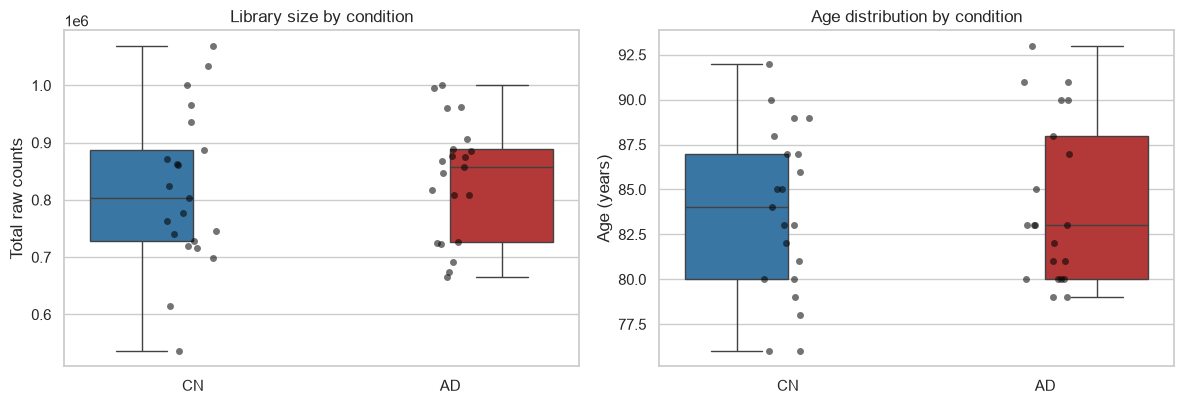

In [5]:
library_sizes = primary_counts.sum(axis=0).rename("library_size").to_frame()
library_sizes = library_sizes.join(primary_metadata[["condition", "sex", "age"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=library_sizes, x="condition", y="library_size", hue="condition",
            legend=False, ax=axes[0], palette={"CN": "#2878B5", "AD": "#C82423"})
sns.stripplot(data=library_sizes, x="condition", y="library_size", color="black",
              alpha=0.55, ax=axes[0])
axes[0].set(title="Library size by condition", xlabel="", ylabel="Total raw counts")

sns.boxplot(data=primary_metadata, x="condition", y="age", hue="condition",
            legend=False, ax=axes[1], palette={"CN": "#2878B5", "AD": "#C82423"})
sns.stripplot(data=primary_metadata, x="condition", y="age", color="black",
              alpha=0.55, ax=axes[1])
axes[1].set(title="Age distribution by condition", xlabel="", ylabel="Age (years)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_input_qc.png", dpi=180, bbox_inches="tight")
plt.show()

## Results

### 5. Fit the adjusted differential-expression model

In [6]:
model_metadata = primary_metadata[["age_centered", "sex", "condition"]].copy()
model_counts = counts_filtered.T.loc[model_metadata.index]

dds = DeseqDataSet(
    counts=model_counts,
    metadata=model_metadata,
    design="~ age_centered + sex + condition",
    refit_cooks=True,
    n_cpus=4,
    quiet=False,
)
dds.deseq2()

stats = DeseqStats(
    dds,
    contrast=["condition", "AD", "CN"],
    alpha=ALPHA,
    n_cpus=4,
    quiet=False,
)
stats.summary()
results = stats.results_df.copy()
results.index.name = "ensembl_id"
results.insert(0, "symbol", symbol_by_id.reindex(results.index).values)
results = results.sort_values(["padj", "pvalue"], na_position="last")

results.to_csv(TABLE_DIR / "deseq2_ad_vs_cn.csv")
print("Model coefficients:", list(dds.varm["LFC"].columns))

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.19 seconds.

Fitting dispersion trend curve...
... done in 0.09 seconds.

Fitting MAP dispersions...


... done in 1.27 seconds.

Fitting LFCs...


... done in 0.77 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition AD vs CN
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ensembl_id                                                                   
ENSG00000187634     5.396803        0.424193  0.439881  0.964337  0.334877   
ENSG00000188290     2.578792        0.491223  0.759055  0.647151  0.517534   
ENSG00000187608    66.600495       -0.125846  0.437168 -0.287866  0.773450   
ENSG00000078808    82.701712       -0.125389  0.088406 -1.418325  0.156096   
ENSG00000176022    14.584042        0.010713  0.175317  0.061108  0.951273   
...                      ...             ...       ...       ...       ...   
ENSG00000212907    62.154974        0.026383  0.145119  0.181803  0.855738   
ENSG00000198886  2077.386076       -0.023216  0.091303 -0.254279  0.799280   
ENSG00000198786   711.870911        0.128257  0.105542  1.215215  0.224284   
ENSG00000198695   193.181617        0.050108  0.122566  0.408828  0.682666   
ENSG000

... done in 0.21 seconds.



### 6. Inspect DESeq2 normalization

DESeq2 estimates a sample-specific size factor with its median-of-ratios
method. These factors normalize systematic differences in sequencing
depth and RNA composition while the negative-binomial model continues to
use integer counts. The log2 counts per million used later are only for
exploratory visualization and are not the input to the differential-
expression test.

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
CN,21.0,1.032945,0.217583,0.663239,0.900592,1.034881,1.078274,1.598449
AD,21.0,1.065726,0.227078,0.697669,0.913850,1.068430,1.143527,1.506644


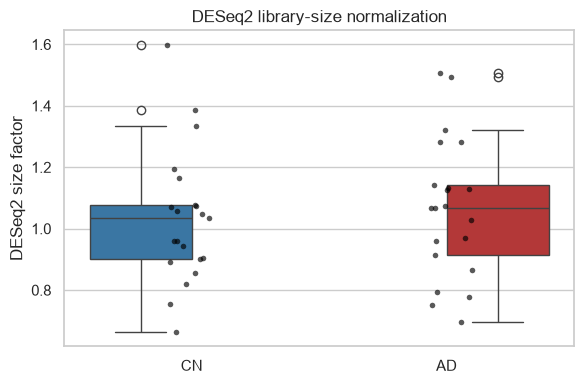

In [7]:
size_factor_qc = (
    dds.obs[["size_factors"]]
    .rename(columns={"size_factors": "DESeq2 size factor"})
    .join(primary_metadata[["condition"]])
)
display(size_factor_qc.groupby("condition")["DESeq2 size factor"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=size_factor_qc, x="condition", y="DESeq2 size factor",
    hue="condition", legend=False, palette={"CN": "#2878B5", "AD": "#C82423"},
    ax=ax,
)
sns.stripplot(
    data=size_factor_qc, x="condition", y="DESeq2 size factor",
    color="black", alpha=0.65, size=4, ax=ax,
)
ax.set(title="DESeq2 library-size normalization", xlabel="")
fig.tight_layout()
plt.show()

### 7. Summarise differential expression

In [8]:
tested = results["padj"].notna()
fdr_sig = tested & (results["padj"] < ALPHA)
robust = fdr_sig & (results["log2FoldChange"].abs() >= MIN_ABS_LFC)
up = robust & (results["log2FoldChange"] > 0)
down = robust & (results["log2FoldChange"] < 0)

result_summary = pd.Series({
    "genes_modelled": len(results),
    "genes_with_FDR": int(tested.sum()),
    "FDR_below_0.05": int(fdr_sig.sum()),
    "robust_DEGs": int(robust.sum()),
    "up_in_AD": int(up.sum()),
    "down_in_AD": int(down.sum()),
}, name="count")
display(result_summary.to_frame())

top_results = results.loc[tested, ["symbol", "baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj"]].head(20)
display(top_results.style.format({
    "baseMean": "{:.1f}", "log2FoldChange": "{:.2f}", "lfcSE": "{:.2f}",
    "pvalue": "{:.2e}", "padj": "{:.2e}",
}))

,count
genes_modelled,9137
genes_with_FDR,9135
FDR_below_0.05,0
robust_DEGs,0
up_in_AD,0
down_in_AD,0


,symbol,baseMean,log2FoldChange,lfcSE,pvalue,padj
ensembl_id,,,,,,
ENSG00000269028,MTRNR2L12,4539.3,0.60,0.14,1.47e-05,1.34e-01
ENSG00000237441,RGL2,32.1,-0.55,0.13,3.69e-05,1.62e-01
ENSG00000185070,FLRT2,4.0,-2.04,0.50,5.32e-05,1.62e-01
ENSG00000075292,ZNF638,81.5,0.34,0.09,8.54e-05,1.95e-01
ENSG00000101079,NDRG3,23.0,-0.57,0.15,1.26e-04,2.31e-01
ENSG00000288920,RPSAP58,8.8,0.91,0.25,2.21e-04,3.37e-01
ENSG00000102753,KPNA3,45.6,0.39,0.11,2.74e-04,3.56e-01
ENSG00000116984,MTR,35.9,0.42,0.12,3.28e-04,3.56e-01
ENSG00000204427,ABHD16A,43.4,-0.41,0.11,3.50e-04,3.56e-01


### 8. PCA of log2 counts per million

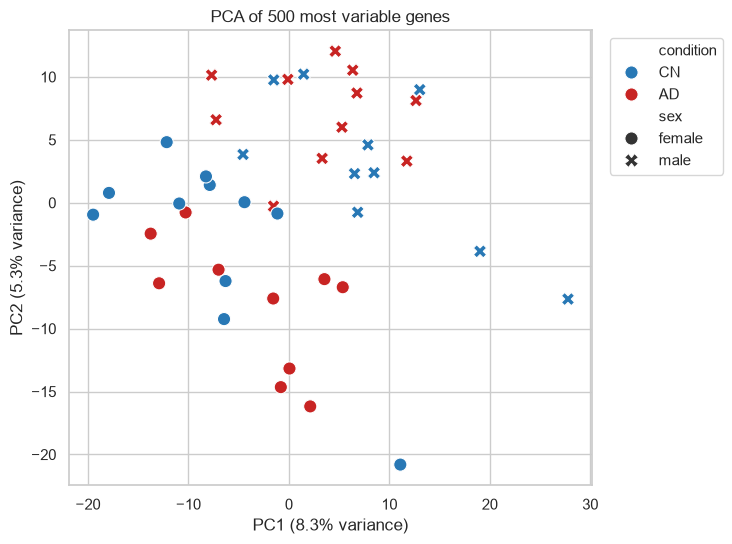

In [9]:
cpm = primary_counts.div(primary_counts.sum(axis=0), axis=1) * 1_000_000
log_cpm = np.log2(cpm + 1)
variable_genes = log_cpm.var(axis=1).nlargest(500).index
pca = PCA(n_components=2, random_state=RANDOM_SEED)
scores = pca.fit_transform(log_cpm.loc[variable_genes].T)
pca_df = primary_metadata.copy()
pca_df["PC1"] = scores[:, 0]
pca_df["PC2"] = scores[:, 1]

fig, ax = plt.subplots(figsize=(7.5, 5.6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="condition", style="sex", s=90,
    palette={"CN": "#2878B5", "AD": "#C82423"}, ax=ax,
)
ax.set(
    title="PCA of 500 most variable genes",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_pca.png", dpi=180, bbox_inches="tight")
plt.show()

### 9. Volcano and MA plots

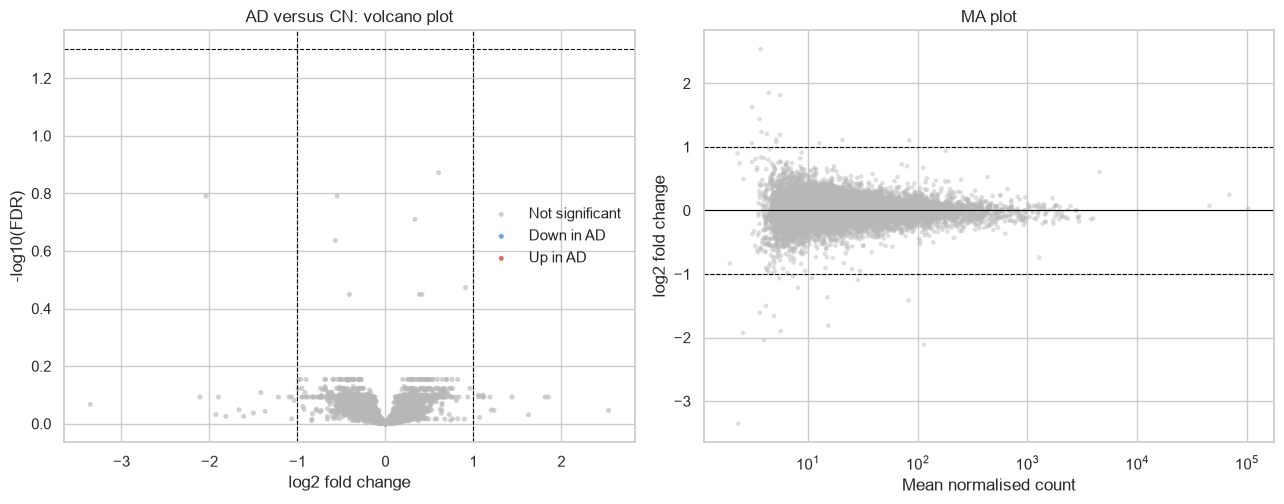

In [10]:
plot_data = results.loc[tested].copy()
plot_data["category"] = "Not significant"
plot_data.loc[up, "category"] = "Up in AD"
plot_data.loc[down, "category"] = "Down in AD"
plot_data["minus_log10_fdr"] = -np.log10(plot_data["padj"].clip(lower=np.finfo(float).tiny))

colors = {"Not significant": "#B7B7B7", "Up in AD": "#C82423", "Down in AD": "#2878B5"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for category in ["Not significant", "Down in AD", "Up in AD"]:
    subset = plot_data.query("category == @category")
    axes[0].scatter(subset["log2FoldChange"], subset["minus_log10_fdr"],
                    s=13, alpha=0.65, c=colors[category], label=category, edgecolors="none")
axes[0].axvline(-MIN_ABS_LFC, color="black", linestyle="--", linewidth=0.8)
axes[0].axvline(MIN_ABS_LFC, color="black", linestyle="--", linewidth=0.8)
axes[0].axhline(-np.log10(ALPHA), color="black", linestyle="--", linewidth=0.8)
axes[0].set(title="AD versus CN: volcano plot", xlabel="log2 fold change", ylabel="-log10(FDR)")
axes[0].legend(frameon=False)

axes[1].scatter(plot_data["baseMean"], plot_data["log2FoldChange"],
                s=11, alpha=0.45, c=plot_data["category"].map(colors), edgecolors="none")
axes[1].set_xscale("log")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(-MIN_ABS_LFC, color="black", linestyle="--", linewidth=0.8)
axes[1].axhline(MIN_ABS_LFC, color="black", linestyle="--", linewidth=0.8)
axes[1].set(title="MA plot", xlabel="Mean normalised count", ylabel="log2 fold change")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_de_overview.png", dpi=180, bbox_inches="tight")
plt.show()

### 10. Expression patterns among the top-ranked genes

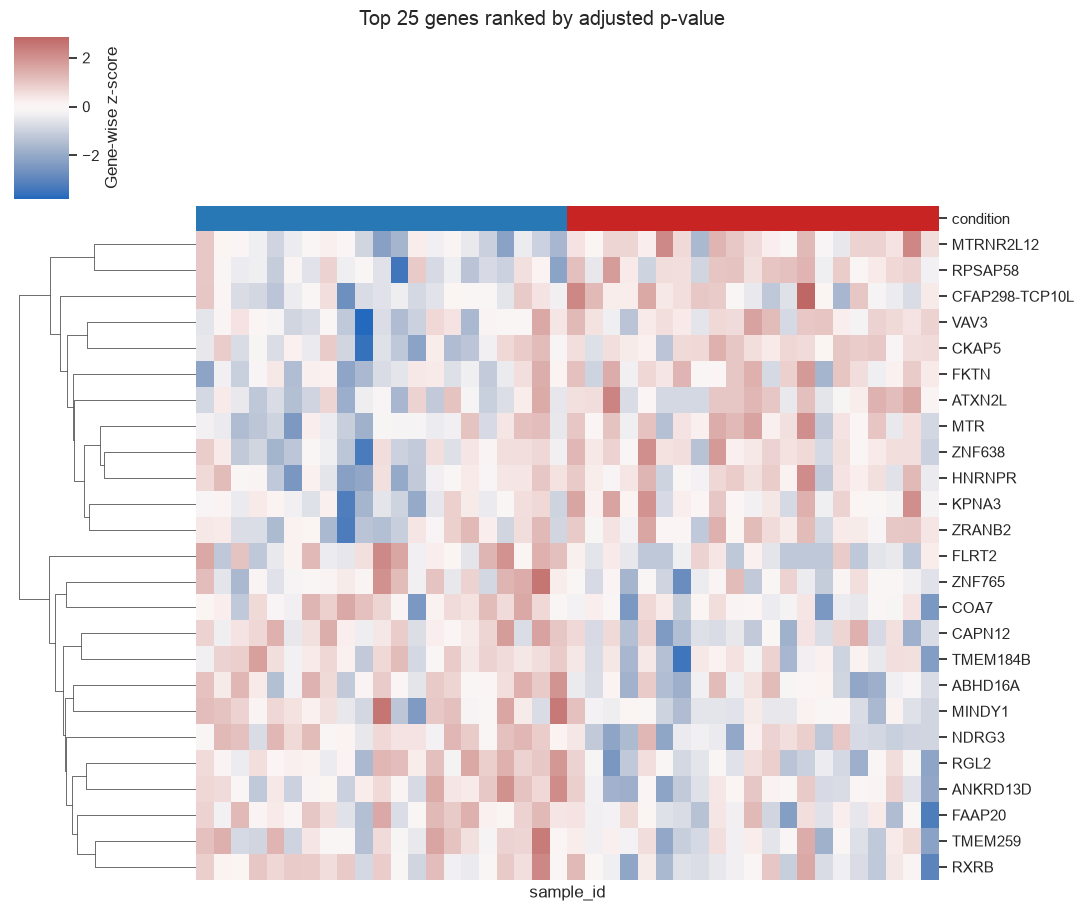

In [11]:
heatmap_genes = results.loc[tested].head(25).index
heatmap_symbols = symbol_by_id.reindex(heatmap_genes).fillna(pd.Series(heatmap_genes, index=heatmap_genes))
heatmap_data = log_cpm.loc[heatmap_genes]
heatmap_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(
    heatmap_data.std(axis=1).replace(0, np.nan), axis=0
).fillna(0)
heatmap_z.index = heatmap_symbols.values

ordered_samples = primary_metadata.sort_values(["condition", "sex", "age"]).index
column_colors = primary_metadata.loc[ordered_samples, "condition"].map(
    {"CN": "#2878B5", "AD": "#C82423"}
)
grid = sns.clustermap(
    heatmap_z[ordered_samples], row_cluster=True, col_cluster=False,
    cmap="vlag", center=0, col_colors=column_colors, xticklabels=False,
    figsize=(11, 9), cbar_kws={"label": "Gene-wise z-score"},
)
grid.fig.suptitle("Top 25 genes ranked by adjusted p-value", y=1.01)
grid.savefig(FIGURE_DIR / "04_top_genes_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

### 11. Pre-specified genes related to the original hypothesis

In [12]:
hypothesis_genes = [
    "MPO", "ELANE", "PADI4", "S100A8", "S100A9", "CLEC5A",
    "APOA1", "APOB", "LPL", "CYP27A1", "NR1H4",
]
hypothesis_table = (
    results[results["symbol"].isin(hypothesis_genes)]
    .loc[:, ["symbol", "baseMean", "log2FoldChange", "pvalue", "padj"]]
    .sort_values("padj", na_position="last")
)
display(hypothesis_table.style.format({
    "baseMean": "{:.1f}", "log2FoldChange": "{:.2f}",
    "pvalue": "{:.2e}", "padj": "{:.2e}",
}))
hypothesis_table.to_csv(TABLE_DIR / "hypothesis_genes.csv", index=False)

,symbol,baseMean,log2FoldChange,pvalue,padj
ensembl_id,,,,,
ENSG00000005381,MPO,3.1,1.06,2.12e-02,7.95e-01
ENSG00000135929,CYP27A1,13.8,-0.46,3.47e-02,8.08e-01
ENSG00000143546,S100A8,431.3,0.52,5.25e-02,8.08e-01
ENSG00000159339,PADI4,42.3,-0.32,1.66e-01,8.95e-01
ENSG00000163220,S100A9,1605.8,0.01,9.47e-01,9.97e-01


### 12. Gene signatures and functional analysis: pre-ranked Hallmark GSEA

Gene signatures are evaluated with the Hallmark collection using a pre-ranked GSEA.

Single-gene testing can miss coordinated, modest shifts across a pathway.
Genes are therefore ranked by the signed AD-versus-CN Wald statistic and
tested against the bundled MSigDB Hallmark collection. Duplicate symbols
are resolved by retaining the entry with the largest absolute statistic.
FDR < 0.05 remains the confirmatory threshold; nominal p-values are shown
only for transparent exploration.

In [13]:
ranked = (
    results.dropna(subset=["symbol", "stat"])
    .assign(abs_stat=lambda frame: frame["stat"].abs())
    .sort_values("abs_stat", ascending=False)
    .drop_duplicates("symbol")
    .sort_values("stat", ascending=False)
    .loc[:, ["symbol", "stat"]]
)

gsea = gp.prerank(
    rnk=ranked,
    gene_sets=str(GMT_FILE),
    permutation_num=1000,
    min_size=15,
    max_size=500,
    seed=RANDOM_SEED,
    threads=4,
    outdir=None,
    verbose=False,
)
pathway_results = gsea.res2d.rename(columns={
    "NOM p-val": "nominal_p", "FDR q-val": "fdr",
    "FWER p-val": "fwer_p", "Lead_genes": "leading_edge",
}).sort_values(["fdr", "nominal_p"])
pathway_results.to_csv(TABLE_DIR / "hallmark_preranked_gsea.csv", index=False)

print(f"Hallmark sets tested: {(len(pathway_results))}")
print(f"Sets at FDR < {ALPHA}: {(pathway_results['fdr'] < ALPHA).sum()}")
display(pathway_results.loc[:, [
    "Term", "ES", "NES", "nominal_p", "fdr", "Tag %", "Gene %"
]].head(12).style.format({
    "ES": "{:.2f}", "NES": "{:.2f}", "nominal_p": "{:.3g}",
    "fdr": "{:.3g}",
}))

Hallmark sets tested: 47
Sets at FDR < 0.05: 0


,Term,ES,NES,nominal_p,fdr,Tag %,Gene %
1,Coagulation,-0.41,-1.61,0.00187,0.0918,19/51,18.81%
2,heme Metabolism,-0.33,-1.56,0.00172,0.0981,75/169,29.46%
0,IL-6/JAK/STAT3 Signaling,-0.41,-1.67,0.0038,0.107,26/58,24.05%
4,UV Response Up,-0.33,-1.48,0.0094,0.125,46/101,28.42%
3,Apical Junction,-0.34,-1.49,0.0108,0.141,37/91,28.14%
5,Notch Signaling,-0.46,-1.43,0.0827,0.155,8/20,15.95%
6,Inflammatory Response,-0.30,-1.39,0.0255,0.191,52/122,29.43%
11,Unfolded Protein Response,-0.31,-1.33,0.0662,0.214,30/92,23.54%
9,Androgen Response,-0.32,-1.34,0.0612,0.224,23/75,18.64%
8,Oxidative Phosphorylation,-0.28,-1.34,0.0293,0.252,43/186,18.17%


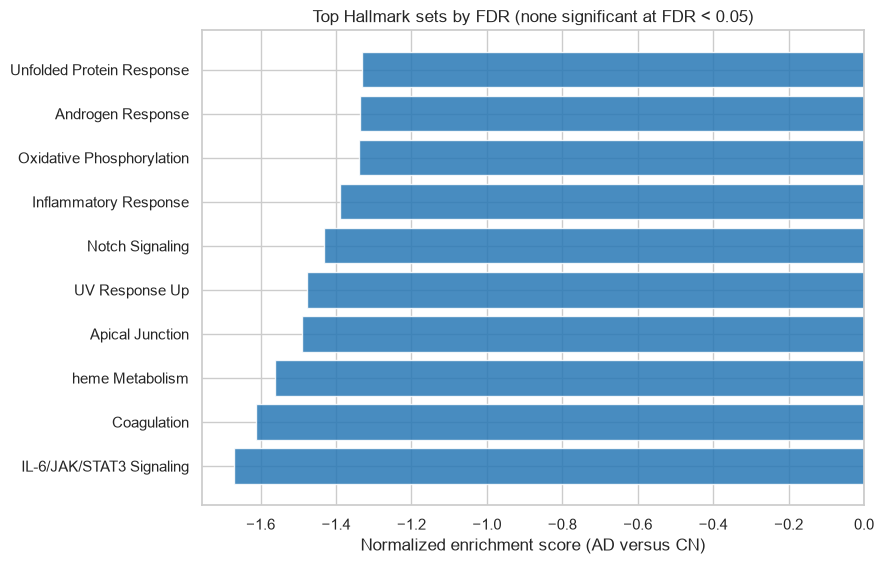

In [14]:
pathway_plot = pathway_results.nsmallest(10, "fdr").copy().sort_values("NES")
pathway_plot["label"] = pathway_plot["Term"].str.replace("Hallmark ", "", regex=False)
colours = np.where(pathway_plot["NES"] >= 0, "#C82423", "#2878B5")

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.barh(pathway_plot["label"], pathway_plot["NES"], color=colours, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Top Hallmark sets by FDR (none significant at FDR < 0.05)",
    xlabel="Normalized enrichment score (AD versus CN)", ylabel="",
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_hallmark_gsea.png", dpi=180, bbox_inches="tight")
plt.show()

The pathway test does not rescue a statistically robust disease signal:
none of the Hallmark sets passes FDR < 0.05. Coagulation, heme metabolism,
IL-6/JAK/STAT3 signalling, and inflammatory response appear among the
stronger negative nominal trends, but their corrected evidence is
insufficient for a discovery claim. These patterns are hypotheses for
independent data, not validated AD biomarkers.

## Discussion and conclusions

The adjusted 21-versus-21 analysis finds no gene or Hallmark pathway at
FDR < 0.05. This is scientifically informative: the dataset does not support
a robust peripheral-blood AD signature under the stated model. It is not
evidence that AD and CN blood are biologically identical, and nominal signals
such as MPO must not be promoted as discoveries after multiple testing.

PCA shows extensive overlap, consistent with strong person-to-person
heterogeneity. Unmeasured leukocyte composition is a particularly plausible
explanation because whole-blood profiles combine several cell populations.
Medication, comorbidities, RNA quality, and batch variables may also confound
the contrast but are unavailable in the metadata used here.

### Strengths

- All available AD and CN samples are analysed instead of one subject per arm.
- Age and sex are adjusted for and thresholds are stated before interpretation.
- Input defects, exclusions, null results, and provenance are reported openly.
- Gene-level results, PCA, heatmap, hypothesis genes, and gene-set enrichment
  provide complementary views without changing the confirmatory threshold.

### Limitations and next steps

- The study is observational and cross-sectional; it cannot establish cause.
- GEO exposes 62 samples although the study summary describes 63 participants.
- Blood-cell proportions and several clinical/technical covariates are absent.
- The executed analysis begins from author-deposited gene counts. Upstream
  mapping is documented separately and must be run on the teaching server to
  independently reproduce the matrix.
- The most useful extension is replication in an independent cohort with
  cell-composition adjustment and a pre-registered model.

## Reproducibility and references

Data and accession metadata are bundled so the notebook can be rerun without
relying on hidden files. Generated tables and figures are written to
`results/`.

- NCBI GEO: [GSE249477](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE249477)
- Associated publication: [PMID 40034360](https://pubmed.ncbi.nlm.nih.gov/40034360/)
- Love, Huber & Anders (2014), DESeq2: [doi:10.1186/s13059-014-0550-8](https://doi.org/10.1186/s13059-014-0550-8)
- Muzellec et al. (2023), PyDESeq2: [doi:10.1093/bioadv/vbad037](https://doi.org/10.1093/bioadv/vbad037)
- Subramanian et al. (2005), GSEA: [doi:10.1073/pnas.0506580102](https://doi.org/10.1073/pnas.0506580102)
- Liberzon et al. (2015), Hallmark gene sets: [doi:10.1016/j.cels.2015.12.004](https://doi.org/10.1016/j.cels.2015.12.004)

Software versions are captured in notebook output. Random procedures use seed
42. See `02_processing_and_QC.ipynb` for the raw-read workflow and
`README.md` for the file map.